<a href="https://colab.research.google.com/github/CasSteur/numeriek-hand-in-1/blob/main/Hand_In_1_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If you are on google-colab you will need to first install sisl
#!pip install sisl

In this notebook, we will set up the skeleton code to perform a Hückel calculation of pyrrole.

In [ ]:
import sisl
import numpy as np
from helper_functions import *

/content/helper_functions.py:98: SyntaxWarning: invalid escape sequence '\m'
  Rvec="\mathbf{{R}}_{dim}".format(dim=dim+1)
/content/helper_functions.py:99: SyntaxWarning: invalid escape sequence '\m'
  kvec="\mathbf{{k}}_{dim}".format(dim=dim+1)
/content/helper_functions.py:102: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "-\imath {Rkvec}".format(Rkvec=Rkvec)
/content/helper_functions.py:105: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "+\imath {Rkvec}".format(Rkvec=Rkvec,sc=-Rdiff[dim])
/content/helper_functions.py:108: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "-\imath {sc} {Rkvec}".format(Rkvec=Rkvec,sc=-Rdiff[dim])
/content/helper_functions.py:112: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "+\imath {sc} {Rkvec}".format(Rkvec=Rkvec,sc=Rdiff[dim])


We will begin with creating a geometry for the pyrrole.

In [ ]:

###The position of each atom
angle1= 107.4 #degrees
angle2= 36.1  #degrees
angle3= 106.6 #degrees
#convert to radians
angle_1= np.radians(angle1) #radians
angle_2= np.radians(angle2) #radians
angle_3= np.radians(angle3) #radians

#set A1 at the origin, positions in angstrum
A1 = [0,0,0]
A2 = [1.34*np.cos(angle_1/2), 1.34*np.sin(angle_1/2),0]
A3 = [2.23*np.cos(angle_2/2),2.23*np.sin(angle_2/2),0]
A4 = [-2.23*np.cos(angle_2/2),2.23*np.sin(angle_2/2),0]
A5 = [-1.34*np.cos(angle_1/2), 1.34*np.sin(angle_1/2),0]

##Position of the atoms, as a numpy array:
posPyr = np.array([A1,A2,A3,A4,A5])

##For a molecule, this choice is not very important, but later, for solids, it will be.
lattice=sisl.Lattice([[10,0,0],[0,10,0],[0,0,10]]) ##We need to specify a lattice and give to SISL
geomPyr = sisl.Geometry(xyz = posPyr, lattice=lattice)

If you set up your geometry correctly, you should see an image of your molecule when you run the code below.
Here we also use the option to color the atoms differently using the `color` option.

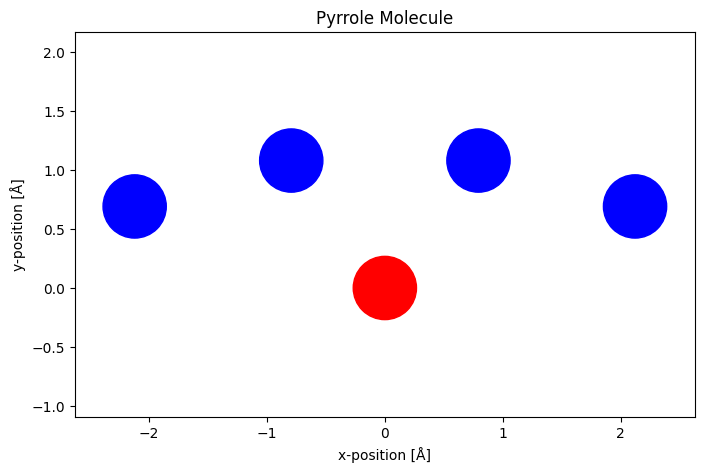

In [ ]:
ColorList=["red","blue","blue","blue","blue"]
PlotGeometry(geomPyr,hold_show=True,color=ColorList);
plt.title("Pyrrole Molecule");

We now add the hoppings

In [ ]:
from IPython.core.application import BaseIPythonApplication

HPyr = sisl.Hamiltonian(geomPyr)
alpha_C= -2 #eV
alpha_N= -3.5 #eV
beta_CN= -1 #eV
beta_CC= -1 #eV
#hopping terms
for i in range(6):
  if i == 0:
    #nitrogen on-site energy
    HPyr[0,0]=alpha_N
  else:
    HPyr[i,i]=alpha_C
  #off-diagonals
  if i <= 4:
    HPyr[i+1,i]=beta_CC
    HPyr[i,i+1]=beta_CC
  else:
    #still make the edge cases for i=5






IndexError: row index is out-of-bounds 5 : 5

It's always a good idea to check that your Hamiltonian is Hermitian and to examine the hopping terms you have added.

In [ ]:
CheckHermiticity(HPyr) ###This checks that the hamiltonian is hermitian
PlotHamTerms(HPyr,hold_show=True,color=ColorList);
plt.title("Pyrrole Molecule");

Now that we have added the Hamiltonian elements. Let's take a look at the Hamiltonian you have created. This can be done in a variety of ways. We can explore the numerical values as an `np.array` with the following command: `H.Hk().todense()`. We can also (and this will be useful later) print the Hamiltonian using the `PrintMomentumRep` command. By default, this prints a generic `a_{i,j}` prefactor, but the actual numbers can also be obtained with the flag `num_pf=True`.

In [ ]:
#Numerical representation
print("Numerical matrix")
display(HPyr.Hk().todense())
#Algebraic representation in TeX
print("Algebraic matrix in Tex")
PrintMomentumRep(HPyr);
#Numeric representation in Tex
print("Numerical matrix in Tex")
PrintMomentumRep(HPyr,num_pf=True);

We now have our Hamiltonian, and it is time to extract the eigenvalues. We could extract the Hamiltonian using the command `H.Hk().todense()`. We then combine this with the eigenvalue solver from numpy, namely `np.linalg.eig()`. Finally, we also sort the eigenvalues with `np.sort`.

In [ ]:
EvsPyr,EVec=np.linalg.eig(HPyr.Hk().todense())
sort_order=np.argsort(EvsPyr)
EvsPyr=EvsPyr[sort_order] ###Sort eigenvalues
EVec=EVec[:,sort_order] ###Sort eigenvectors

plt.plot(EvsPyr,"or--",label="Pyrrole")
plt.ylabel(r"Energy [Ev]")
plt.xlabel("Eigenstate number")
plt.legend();

Now that we have our eigenvalues sorted we can immediately plot the eigenvalues as a matrix using `imshow`

In [ ]:
EProb=np.square(np.abs(EVec))
vmax=np.max(EProb)
plt.imshow(EProb,vmax=vmax,vmin=0)
plt.colorbar()

The `imshow` above is nice, but we are now going to do something even more helpful: If you have set up your geometry correctly, we can now plot what the eigenstates look like. For this, we can use the `color` and `AtomRadius` attributes.

In [ ]:
def NumToCol(Num,cmap="viridis",vmin=0,vmax=1):
    """Turning a number into a color in the colormap"""
    #print("Num:",Num)
    r = (Num - vmin)/(vmax - vmin)
    return plt.get_cmap(cmap)(r)

In [ ]:
for i in range(5):
    EPi=np.array(EProb[:,i])
    ###Convert the prbability to a color
    ColList = [NumToCol(x[0],vmax=vmax,vmin=0) for x in EPi]
    ###Convert the prbability to a radius
    ##we use the square root so tha tthe are of the curcle is proprtional to the prbability
    RadList = [np.sqrt(x[0]) for x in EPi]
    PlotGeometry(geomPyr,hold_show=True,color=ColList,AtomRadius=RadList);
    plt.title("Pyrrole Molecule Eig no "+str(i)+", E="+str(EvsPyr[i]))

While we are at it, let's also compute the effective number of electrons on each atom. This can calculated from

\begin{equation}
q_i = \sum_{k = 1}^K n_k c_{i,k}^2
\end{equation}

where the sum runs over the occupied orbitals, $n_k$ indicates the number of electrons in orbital $k$ and $c_{i,k}$ is the coefficient of atom $i$ for orbital $k$. The total number of effective electrons should, of course, equal the actual number of electrons, i.e. $\sum_{i}q_i =\#\mathrm{electrons}$.

In [ ]:
qList = np.zeros(5)
qList[1] = ???
qList[2] = ???
qList[3] = ???

For fun, we can also plot the electronic occupancy of our molecule.
We will use the square root of the occupancy so that the area of the circle is proportional to the probability. We will also adapt the overall radius so that the circles will not overlap.

In [ ]:
###Plot the atomic occupancy
PlotGeometry(geomPyr,hold_show=True,color=ColorList,AtomRadius=0.5*np.sqrt(qList));
plt.title("Pyrrole Molecule atomic occupancy");

We are now ready to compute the dipole moment of a pyrrole using the partial charges on the atoms and their coordinates. The expression for the $y$-component of the dipole moment is
\begin{equation}
	\mu_y = \sum_i Q_iy_i
\end{equation}
where the sum is over the atoms in the molecule. $Q_i$ denotes the net (partial) charge on atom $i$.


In [ ]:
mu = ???